In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv("HousePricePrediction.csv")

dataset.head(5)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [ ]:
dataset.shape

(2919, 13)

In [ ]:
object_cols = dataset.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

int_cols = dataset.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_cols))

fl_cols = dataset.select_dtypes(include=['float64']).columns
print("Float variables:", len(fl_cols))

Categorical variables: 4
Integer variables: 6
Float variables: 3


Heatmap saved as correlation_heatmap.png


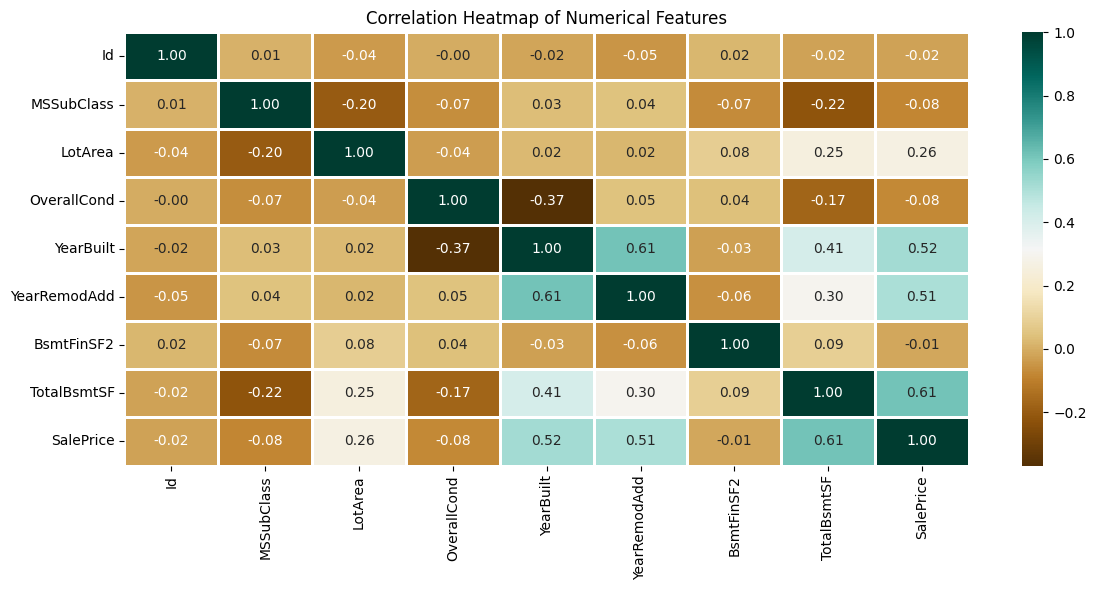

In [ ]:
numerical_dataset = dataset.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

<Axes: title={'center': 'No. Unique values of Categorical Features'}, xlabel='None'>

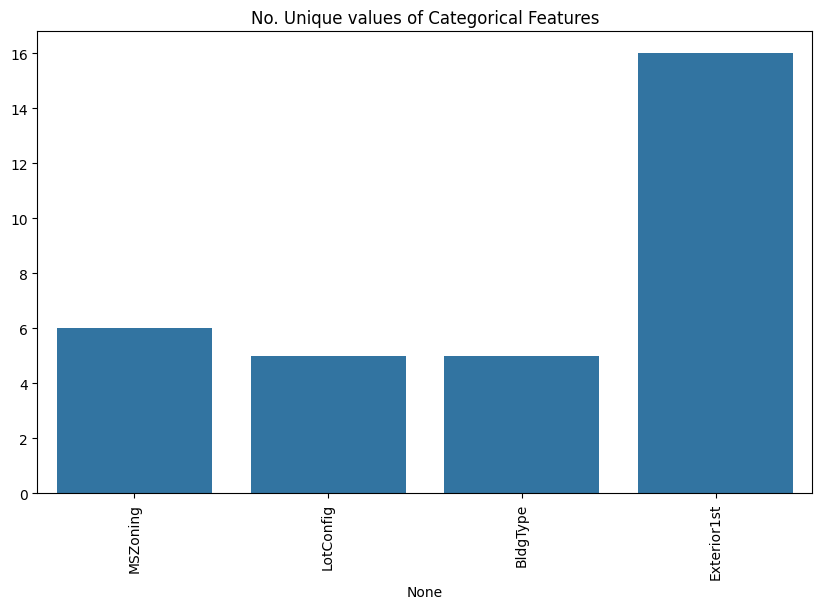

In [ ]:
unique_values = []
for col in object_cols:
  unique_values.append(dataset[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)

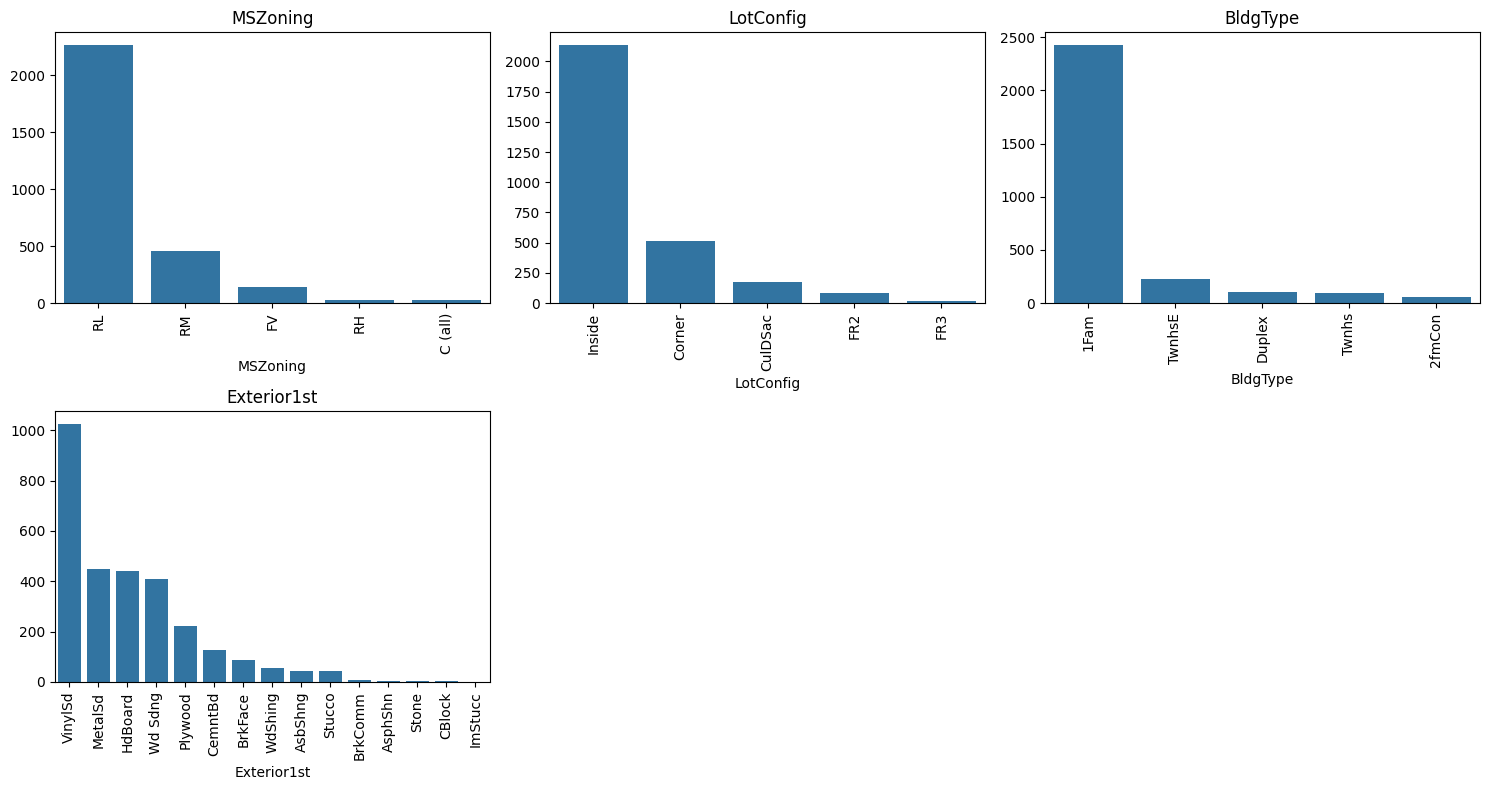

In [ ]:
import math

n = len(object_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(object_cols, 1):
    plt.subplot(rows, cols, i)
    y = dataset[col].value_counts()
    sns.barplot(x=y.index, y=y.values)
    plt.xticks(rotation=90)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
dataset.drop(['Id'],
             axis=1,
             inplace=True)

In [ ]:
dataset['SalePrice'] = dataset['SalePrice'].fillna(
  dataset['SalePrice'].mean())

In [ ]:
new_dataset = dataset.dropna()

In [ ]:
new_dataset.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,0
BsmtFinSF2,0
